# 07 — Qualitative triangulation: reading the books behind the numbers

Everything so far has been a number attached to a label. Notebook 05 reported that character
appearance content is markedly *lower* in well-rated romance, and interpreted that as a claim
about writing craft. But "Character Appearance & Self-Presentation" is a name an LLM gave to a
cluster of sentences, and the interpretation was mine. Neither has been checked against the
actual prose.

This notebook does that check. It pulls real sentences out of the corpus for the books at the
extremes of each headline index and asks the only question that matters: **does the text read
the way the number says it should?**

**The problem with reading examples, and how it is handled here.** In a 16,000-book corpus,
anyone can find quotations supporting anything. So the choice of what to read is taken away
from the reader entirely:

1. The *quantitative result* names the index.
2. A **2x2 design** names the cells — high and low index, crossed with high and low rating
   tier. The off-diagonal cells are mandatory, not optional.
3. A **fixed seed** names the books within each cell.
4. The *topic model* names the sentences: the ones it was most confident about.

Nothing in that chain is a judgement call, which means an unflattering example cannot be
quietly dropped.

**Why the off-diagonal cells carry the weight.** A high-appearance book that is *badly* rated
is easy to explain. A high-appearance book that is *well* rated is the interesting one,
because it shows what the index looks like when the association fails. If the two read the
same way, the index is measuring something real that simply does not always matter. If they
read differently, the index is conflating two things and the finding needs qualifying.

In [1]:
import glob
import sys
import textwrap
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = cwd
for _ in range(6):
    if (project_root / "configs").is_dir() and (project_root / "src").is_dir():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Could not find project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.stage10_correlation_analysis.analysis import effects as eff
from src.stage10_correlation_analysis.analysis import notebook_helpers as nbh
from src.stage10_correlation_analysis.analysis import qual

ctx = nbh.setup("07_qualitative_triangulation")
cfg = ctx.cfg
TIER_COL = cfg.tier_column
HIGH, LOW = cfg.section("tiers", "headline_contrast")
SEED = int(cfg.section("qualitative", "seed"))
BOOKS_PER_CELL = int(cfg.section("qualitative", "books_per_cell"))
SENTENCES_PER_BOOK = int(cfg.section("qualitative", "sentences_per_book"))
QUANTILES = list(cfg.section("qualitative", "index_quantiles"))

frame = nbh.load_analysis_frame(cfg).reset_index()
topic_lookup = nbh.load_topic_lookup(cfg)
book_topic_counts = nbh.load_hard_counts(cfg, "book_topic_counts")
books_meta = pd.read_csv(cfg.path("inputs", "books_meta"))

SENTENCE_FILES = [
    Path(p) for p in sorted(glob.glob(str(cfg.path("inputs", "sentence_topics_glob"))))
]
# Very short strings dominate a top-confidence ordering — dialogue tags, fragments left by
# sentence splitting. They are legitimate corpus content but useless to read, so close-reading
# extracts are drawn from sentences long enough to carry meaning.
MIN_SENTENCE_CHARS = 60

print(f"{len(frame):,} books | {len(SENTENCE_FILES)} sentence parquet files")
print(f"Sampling: {BOOKS_PER_CELL} books per cell, seed {SEED}, "
      f"index quantiles {QUANTILES}")

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage10/final_analysis.yaml
Run          : v4_l12_granular_final_call49
Model        : BERTopic call_49 — MiniLM-L12, 374 topics (348 mapped + outliers)
Outputs      : results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation


16,000 books | 3 sentence parquet files
Sampling: 5 books per cell, seed 42, index quantiles [0.1, 0.9]


## 1. Which findings need checking, and why

Four results are put in front of the text. They were chosen because each carries an
interpretation that the numbers alone cannot establish.

In [2]:
TARGETS = [
    {
        "column": "abs_leaf_1.6",
        "leaf": "1.6",
        "short": "appearance",
        "claim": "Character appearance and self-presentation is LOWER in well-rated books "
                 "(delta -0.145). Interpreted in notebook 05 as a craft marker: heavy physical "
                 "description signals weaker prose.",
        "to_check": "Do low-rated high-appearance books actually read as description-heavy, and "
                    "does the well-rated high-appearance cell read differently?",
    },
    {
        "column": "abs_leaf_7.2",
        "leaf": "7.2",
        "short": "violence",
        "claim": "Violence, threats and non-sexual coercion is HIGHER in well-rated books "
                 "(delta +0.162), the largest effect in the analysis. Interpreted as external "
                 "threat: danger from outside the couple.",
        "to_check": "Is the violence external to the relationship, or is some of it the hero "
                    "threatening the heroine? The interpretation depends entirely on which.",
    },
    {
        "column": "abs_leaf_2.3",
        "leaf": "2.3",
        "short": "explicit sex",
        "claim": "Explicit sexual acts predict REACH strongly (delta +0.165) and rating barely "
                 "(+0.027). Notebook 06's reading: explicitness sells without being liked more.",
        "to_check": "Are high-explicitness books distinguishable in kind, or only in quantity? "
                    "And what fills the space in the low-explicitness cell?",
    },
    {
        "column": "abs_leaf_4.4",
        "leaf": "4.4",
        "short": "couple conflict",
        "claim": "Conflict, distance and breakup threats predicts REACH (+0.153) and is mildly "
                 "negative on rating (-0.039) — the dark leaf that broke H5's composite.",
        "to_check": "Is this the couple fighting, as the label implies, rather than external "
                    "conflict? H5's whole internal-versus-external reading rests on it.",
    },
]

overview = pd.DataFrame([
    {"index": t["column"], "leaf": t["leaf"],
     "leaf_name": topic_lookup.loc[
         topic_lookup["taxonomy_main_id"] == t["leaf"], "taxonomy_main_name"
     ].iloc[0] if (topic_lookup["taxonomy_main_id"] == t["leaf"]).any() else "?",
     "n_topics": int((topic_lookup["taxonomy_main_id"] == t["leaf"]).sum()),
     "mean_share_pct": frame[t["column"]].mean() * 100,
     "what_to_check": t["to_check"]}
    for t in TARGETS
])
display(overview.round(3))
ctx.save_table(overview, "triangulation_targets")

,index,leaf,leaf_name,n_topics,mean_share_pct,what_to_check
0,abs_leaf_1.6,1.6,Character Appearance & Self-Presentation,15,3.3400,Do low-rated high-appearance books actually re...
1,abs_leaf_7.2,7.2,"Violence, Threats & Non-Sexual Coercion",13,2.1130,"Is the violence external to the relationship, ..."
2,abs_leaf_2.3,2.3,Explicit Sexual Acts,7,2.9310,Are high-explicitness books distinguishable in...
3,abs_leaf_4.4,4.4,"Conflict, Distance & Breakup Threats",8,4.5350,"Is this the couple fighting, as the label impl..."


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/triangulation_targets.csv  (4 rows)


## 2. The sampling machinery

One function per target, applied identically. It picks the books, pulls the sentences, and
renders them. The only latitude left is which of the four cells to read first.

In [3]:
def leaf_topics(leaf_id: str) -> list:
    return topic_lookup.loc[
        topic_lookup["taxonomy_main_id"] == leaf_id, "topic_id"
    ].astype(int).tolist()


def close_read(target: dict) -> dict:
    """Sample the 2x2, fetch sentences from the leaf's own topics, and build a pack."""
    column, leaf = target["column"], target["leaf"]
    topics = leaf_topics(leaf)

    sampled = qual.sample_extreme_books(
        frame.set_index("book_id"), column, TIER_COL,
        tier_high=HIGH, tier_low=LOW,
        quantiles=QUANTILES, books_per_cell=BOOKS_PER_CELL, seed=SEED,
        extra_columns=["rating_shrunk", "n_ratings", "genre_group", "publication_year"],
    )
    book_ids = sampled["book_id"].astype(int).tolist()

    # Over-fetch, then keep only sentences long enough to be worth reading.
    raw = qual.fetch_sentences(
        SENTENCE_FILES, book_ids, topics,
        per_book_topic=SENTENCES_PER_BOOK * 4, threads=8,
    )
    if not raw.empty:
        raw = raw[raw["sentence"].str.len() >= MIN_SENTENCE_CHARS]
        raw = raw.sort_values(["book_id", "topic_id", "max_topic_prob"], ascending=[True, True, False])
        raw["rank_in_topic"] = raw.groupby(["book_id", "topic_id"]).cumcount() + 1
        raw = raw[raw["rank_in_topic"] <= 3]

    top_topics = qual.top_loading_topics(
        book_topic_counts, book_ids, topic_lookup, top_n=4, restrict_to_topics=topics,
    )
    pack = qual.build_close_reading_pack(sampled, top_topics, raw, books_meta)
    contrast = qual.contrast_summary(sampled, column)
    return {"target": target, "sampled": sampled, "pack": pack, "contrast": contrast,
            "n_topics": len(topics)}


def show_cell(pack: pd.DataFrame, cell: str, *, max_books: int = 3,
              max_topics: int = 2, max_sentences: int = 2) -> None:
    """Print one cell of the 2x2 in readable form."""
    subset = pack[pack["cell"] == cell]
    header = cell.replace("_", " ")
    print("=" * 92)
    print(f"  {header.upper()}")
    print("=" * 92)
    if subset.empty:
        print("  (no sentences retrieved for this cell)")
        return
    for book_id, rows in list(subset.groupby("book_id", sort=False))[:max_books]:
        first = rows.iloc[0]
        print(f"\n  {first.get('title', '?')} — {first.get('author_name', '?')}")
        print(f"  rating {first.get('average_rating_weighted_mean', float('nan')):.2f}, "
              f"{int(first.get('ratings_count_sum', 0)):,} ratings")
        for (topic_id, label), topic_rows in list(
            rows.groupby(["topic_id", "label"], sort=False)
        )[:max_topics]:
            share = float(topic_rows["share"].iloc[0])
            print(f"    · topic {topic_id} — {label}  ({share:.2%} of the book)")
            for _, row in topic_rows.head(max_sentences).iterrows():
                text = " ".join(str(row["sentence"]).split())
                for line in textwrap.wrap(text, width=84)[:3]:
                    print(f"        {line}")
    print()


results = {}
for target in TARGETS:
    results[target["short"]] = close_read(target)
    print(f"{target['short']}: "
          f"{results[target['short']]['pack']['book_id'].nunique()} books with sentences, "
          f"{len(results[target['short']]['pack'])} extracts, "
          f"{results[target['short']]['n_topics']} topics in the leaf")

appearance: 20 books with sentences, 228 extracts, 15 topics in the leaf


violence: 18 books with sentences, 163 extracts, 13 topics in the leaf


explicit sex: 20 books with sentences, 176 extracts, 7 topics in the leaf


couple conflict: 20 books with sentences, 131 extracts, 8 topics in the leaf


### How different are the sampled books, before reading them?

Worth establishing first. If the high and low cells barely differ on the index, no amount of
close reading will show anything.

In [4]:
contrast_all = pd.concat(
    [r["contrast"].assign(index=name) for name, r in results.items()], ignore_index=True
)
contrast_all["mean_index_pct"] = contrast_all["mean_index"] * 100
display(
    contrast_all.pivot_table(index="index", columns="cell", values="mean_index_pct").round(3)
)
ctx.save_table(contrast_all, "cell_contrasts")
print(
    "Values are the mean share of a book's sentences, in percent. The high cells run several\n"
    "times the low cells on every index, so the sampled books are genuinely far apart on the\n"
    "thing being measured — the close reading is not being asked to detect a hairline difference."
)

cell,high_index_high_tier,high_index_low_tier,low_index_high_tier,low_index_low_tier
index,,,,
appearance,6.9840,5.9990,1.8710,1.8270
couple conflict,8.2900,8.4780,1.9680,2.1560
explicit sex,10.4120,12.2920,0.2260,0.4500
violence,6.4360,5.8950,0.6030,0.5030


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/cell_contrasts.csv  (16 rows)
Values are the mean share of a book's sentences, in percent. The high cells run several
times the low cells on every index, so the sampled books are genuinely far apart on the
thing being measured — the close reading is not being asked to detect a hairline difference.


## 3. Appearance: is it really a craft marker?

The claim to check: heavy physical description marks weaker prose. The alternative the
numbers cannot rule out is that appearance content marks a *subgenre* — that
appearance-heavy books are, say, paranormal or erotic romance, and the rating difference is
really a subgenre difference.

Reading the high-index cells against each other is the test.

In [5]:
print(results["appearance"]["target"]["claim"])
print()
show_cell(results["appearance"]["pack"], "high_index_low_tier")

Character appearance and self-presentation is LOWER in well-rated books (delta -0.145). Interpreted in notebook 05 as a craft marker: heavy physical description signals weaker prose.

  HIGH INDEX LOW TIER

  Succubus in the City — Nina Harper
  rating 3.21, 399 ratings
    · topic 18 — Ordering A Gown For Her  (1.63% of the book)
        Those were the fashions of the day, and when I told you I thought some of those
        dresses were fabulous on you, I was telling the truth.
        I kept that in mind when I chose a suit in a coppery and olive tweed, with a slender
        skirt to the knee and the new boots.
    · topic 218 — Resenting Someone More Attractive  (0.82% of the book)
        In the fish-eye lens it was hard to tell for sure, but he seemed awfully attractive.
        Because I thought he was the most attractive man I’d seen in ages, decades probably.

  Bond of Trust — Anitra Lynn McLeod
  rating 3.60, 80 ratings
    · topic 170 — Staying Close Despite Long Separation

In [6]:
show_cell(results["appearance"]["pack"], "high_index_high_tier")

  HIGH INDEX HIGH TIER

  The Guardian — Sherrilyn Kenyon
  rating 4.34, 15,571 ratings
    · topic 364 — Noticing What He Wears  (2.45% of the book)
        The black pants that buttoned on the sides were extremely uncomfortable and they
        only went to his knees.
        And weird buckled shoes that pinched his toes and rubbed his heels worse than his
        armored boots.
    · topic 18 — Ordering A Gown For Her  (2.10% of the book)
        I have to say that I’m glad you’re the only one she wants dressed this way. ‘
        Even worse than the curly mess he couldn’t control were the clothes Lydia had picked
        out for him to wear.

  Vampire in Paradise — Sandra Hill
  rating 4.11, 545 ratings
    · topic 18 — Ordering A Gown For Her  (0.95% of the book)
        Especially wearing that white silk gown that showed her lack of underwear every time
        she moved.
        You are wearing something under that wanton garment, aren’t you?”
    · topic 364 — Noticing What He

In [7]:
show_cell(results["appearance"]["pack"], "low_index_high_tier")

  LOW INDEX HIGH TIER

  Medusa, A Love Story — Sasha Summers
  rating 4.20, 378 ratings
    · topic 170 — Staying Close Despite Long Separation  (0.51% of the book)
        Until it became clear that the pair were otherwise occupied.
        This couple was so absorbed in one another that he wondered.
    · topic 218 — Resenting Someone More Attractive  (0.42% of the book)
        He was handsome – more handsome than any man she’d ever seen.
        He was too handsome to be such a sullen creature, and his brother at that.

  Master's Pet — Jan Bowles
  rating 4.13, 65 ratings
    · topic 170 — Staying Close Despite Long Separation  (0.63% of the book)
        It was a ritual they’d enjoyed many times, and highlighted the dynamics of their
        relationship.
        It had been a wonderful day some nine months ago now, and had sealed their
        commitment to each other.
    · topic 77 — Haircut and Grooming Offered  (0.29% of the book)
        Broad shoulders, short blond hair, 

### What the appearance cells actually show — and it is not what notebook 05 claimed

**The two high-index cells read the same way.** Both are full of clothing: gowns being
ordered, outfits catalogued, hair described. Sherrilyn Kenyon's *The Guardian* (4.34, 15,571
ratings) spends 2.45% of its sentences on what a character is wearing and is one of the
best-rated books in the corpus. *Succubus in the City* (3.21) does something very similar at
1.63%. If heavy appearance description were a craft marker, these cells should differ in kind.
They do not.

So the notebook 05 interpretation — "appearance description signals weaker prose" — is **not
supported by the text**. The statistical association is real and reasonably large, but the
mechanism proposed for it does not survive contact with the sentences.

**Two things the close reading did establish, both unwelcome.**

*The leaf is contaminated by topics that are not about appearance.* Look at which topics the
sampler chose: alongside "Ordering A Gown For Her" and "Noticing What He Wears" sits topic 170,
"Staying Close Despite Long Separation", whose sentences are about emotional connection and
contain no physical description at all. Section 7 quantifies how much of the leaf this affects.

*At least one sampled book is not a romance novel.* "Midlife" by Harry Pants returns sentences
like *"According to the Oxford English Dictionary it can be a 'knitted pullover'..."* and
*"The phrase derives from an early use of 'colors' to mean flag, pennant, or badge."* This is
reference prose about clothing history, not fiction. It scores high on the appearance index
for exactly the wrong reason. Section 8 asks how common that is.

## 4. Violence: external threat or intimate coercion?

This is the single most consequential check in the notebook. Notebook 05 reported that
violence and non-sexual coercion is the strongest positive theme signal in the corpus, and
read it as *external* threat — suspense plots, danger from outside the couple. If the
sentences instead show the love interest threatening the protagonist, the same number means
something very different and considerably more uncomfortable.

In [8]:
print(results["violence"]["target"]["claim"])
print()
show_cell(results["violence"]["pack"], "high_index_high_tier", max_books=4)

Violence, threats and non-sexual coercion is HIGHER in well-rated books (delta +0.162), the largest effect in the analysis. Interpreted as external threat: danger from outside the couple.

  HIGH INDEX HIGH TIER

  Desire Unchained — Larissa Ione
  rating 4.25, 28,255 ratings
    · topic 51 — Locked Up By A Vampire  (1.81% of the book)
        I mean, what’s to stop a vamp from just leaving them for dead instead of giving them
        the exchange of the vamp’s own blood?” “
        Yeah, well, that was before I caught you in bed with two vampires.
    · topic 87 — Threatening Death As A Warning  (1.14% of the book)
        I know what you heard, but I swear to you, I’m not going to kill you.” “

  A Touch of Midnight — Lara Adrian
  rating 4.09, 7,816 ratings
    · topic 113 — Knife Handed Over For Combat  (3.02% of the book)
        He picked up Faulkner’s sword and drove it into Smithson’s chest.
        With a flex of his shoulder, he thrust the sword deep, severing throat and spin

In [9]:
show_cell(results["violence"]["pack"], "high_index_low_tier")

  HIGH INDEX LOW TIER

  Blood Brothers — Barbara Sheridan
  rating 3.05, 93 ratings
    · topic 87 — Threatening Death As A Warning  (1.30% of the book)
        Don’t get in my way when I kill him or I’ll take your head too.”
        I heard you crying in your sleep to Watts that you didn’t mean to kill him.” “
    · topic 51 — Locked Up By A Vampire  (1.27% of the book)
        She’s a most unusual vampire, to be sure, and that explains the presence of the
        other.” “
        You and all those other fucking vampires or whatever the hell you are, you sick
        fuck!”

  Praefatio — Georgia McBride
  rating 3.36, 66 ratings
    · topic 87 — Threatening Death As A Warning  (1.03% of the book)
        If I could have killed him, right then and there, I would have.
        He’ll kill me if I let you get hurt, or worse, killed while the humans are out here
        hunting for … Fallen, vampires, and witches.” “
    · topic 148 — Banished From The Ranch  (0.87% of the book)
       

### The violence check passes, and it passes clearly

**The external-threat reading is correct.** The well-rated high-violence cell is paranormal
and romantic-suspense: Larissa Ione's *Desire Unchained* (4.25, 28,255 ratings) with vampires
and captivity, Lara Adrian's *A Touch of Midnight* with sword combat, *Nearly Mended* with
gunfire and abduction. The violence is plot violence — antagonists, weapons, sieges. Not one
extract shows the love interest threatening the protagonist.

This matters because the alternative reading would have been serious. "Violence and coercion
is higher in well-rated romance" could have meant that readers reward intimate-partner
threat, which would be a claim requiring great care. The text says instead that well-rated
romance is disproportionately *romantic suspense and paranormal romance* — subgenres with
external antagonists and high-stakes plots. That is a claim about subgenre and pacing, not
about readers enjoying menace from a partner.

The qualification, stated because the topic list below makes it visible: the leaf is not
*purely* external. Topic 82, "Touch Her and Your Family Suffers", carries about 9% of the
leaf and is coercion aimed at forcing a woman's compliance, and topic 78, "Swearing War
Before He Takes Her", is possessive as much as protective. So a minority of this leaf is
intimate coercion after all. The dominant reading is external threat, and the honest version
of the sentence is "mostly external" rather than "external".

**It also reframes the finding as partly a subgenre effect.** Both the strongest extracts are
paranormal. Notebook 08's genre-subgroup check becomes the necessary follow-up: is violence
still associated with rating *within* paranormal romance, or is the whole effect that
paranormal romance is rated higher and happens to contain fights?

**The low-rated cell contains a second non-romance book.** *The Great British Date Off* by
Sheila Brady returns *"The M. Gun had to be abandoned in a shell hole our men being too
exhausted to carry it"* and *"They came on with the infantry, ranging their little engines to
the farm"*. This is First World War military history. The title suggests a romantic comedy;
the text is nonfiction. That is now two contaminated books found by reading twenty-four.

### Who is the violence aimed at? A structural check

Reading a handful of sentences is suggestive, not decisive. A harder check uses the topic
model itself: the Stage08 labelling pipeline recorded a `consent_status` per topic, and
Stage09 recorded whether a topic belongs to the intimate-coercion watchlist. If the
well-rated books' violence mass sits in topics flagged as intimate coercion, the external
reading is wrong.

In [10]:
violence_topics = leaf_topics("7.2")
coercion_flags = topic_lookup[topic_lookup["topic_id"].isin(violence_topics)][
    ["topic_id", "label", "consent_status", "sexual_function",
     "taxonomy_use_in_theory_watchlist", "taxonomy_mechanic_tags"]
].copy()

mass = book_topic_counts[book_topic_counts["topic_id"].isin(violence_topics)].groupby(
    "topic_id", as_index=False
)["n_sentences"].sum().rename(columns={"n_sentences": "corpus_sentences"})
coercion_flags = coercion_flags.merge(mass, on="topic_id", how="left")
coercion_flags["share_of_leaf"] = (
    coercion_flags["corpus_sentences"] / coercion_flags["corpus_sentences"].sum()
)
coercion_flags = coercion_flags.sort_values("share_of_leaf", ascending=False)
display(coercion_flags.round(4))
ctx.save_table(coercion_flags, "violence_topic_flags")

not_applicable = coercion_flags.loc[
    coercion_flags["consent_status"].isin(["not_applicable", "none"]), "share_of_leaf"
].sum()
print(
    f"\n{not_applicable:.1%} of the leaf's sentence mass sits in topics whose consent status is\n"
    "'not applicable' — that is, topics with no sexual or intimate dimension at all. That is the\n"
    "structural evidence for the external-threat reading: most of this leaf is not about the\n"
    "couple's interaction."
)

,topic_id,label,consent_status,sexual_function,taxonomy_use_in_theory_watchlist,taxonomy_mechanic_tags,corpus_sentences,share_of_leaf
3,87,Threatening Death As A Warning,not_applicable,none,True,"external_threat, forceful_intensity",436050,0.1779
1,78,Swearing War Before He Takes Her,coercion_watchlist,consent_boundary,True,"possessive_control, protective_care, forceful_...",271732,0.1109
4,91,Arguing Over Guns and Weapons,not_applicable,none,True,external_threat,231851,0.0946
5,113,Knife Handed Over For Combat,not_applicable,none,False,external_threat,219446,0.0895
2,82,Touch Her and Your Family Suffers,coercion_watchlist,consent_boundary,True,"external_threat, possessive_control, ambiguous...",210556,0.0859
9,249,Threatened With Arrest and Jail,not_applicable,none,False,external_threat,179083,0.0731
6,114,Guns Aimed Across The Room,not_applicable,none,False,external_threat,164793,0.0672
7,117,Blamed and Threatened Into Compliance,coercion_watchlist,none,True,"possessive_control, external_threat, forceful_...",142537,0.0582
11,294,Accepting Whatever Punishment Is Deserved,coercion_watchlist,none,True,"possessive_control, forceful_intensity, ambigu...",137652,0.0562
0,51,Locked Up By A Vampire,not_applicable,none,True,"possessive_control, external_threat",136114,0.0555


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/violence_topic_flags.csv  (13 rows)

68.9% of the leaf's sentence mass sits in topics whose consent status is
'not applicable' — that is, topics with no sexual or intimate dimension at all. That is the
structural evidence for the external-threat reading: most of this leaf is not about the
couple's interaction.


## 5. Explicit sex: quantity or kind?

The two-channel result was that explicitness travels with audience size but not with
approval. Reading the cells asks whether high-explicitness books differ from low ones in
*how* they write sex or only in *how much*, and what the low-explicitness books do with the
space instead.

In [11]:
print(results["explicit sex"]["target"]["claim"])
print()
show_cell(results["explicit sex"]["pack"], "high_index_high_tier", max_books=2)

Explicit sexual acts predict REACH strongly (delta +0.165) and rating barely (+0.027). Notebook 06's reading: explicitness sells without being liked more.

  HIGH INDEX HIGH TIER

  Second Thoughts — Ian Dalton
  rating 4.15, 207 ratings
    · topic 7 — Kissing With Tongue and Urgency  (10.22% of the book)
        She reached up and held his face with both hands as she slid her tongue into his
        mouth, kissing him deeply.
        She placed her lips on his chest and sucked at his flesh for a moment before heading
        lower trailing kisses down his abdomen.
    · topic 292 — Erection Straining Against His Trousers  (2.38% of the book)
        His cock was slick from his excitement and she stroked him harder and harder.
        His cock was rock hard and he considered jerking off right there so he could hold
        out longer for her.

  Endure — S.E. Hall
  rating 4.43, 553 ratings
    · topic 41 — Gripping Her Neck and Pulling Close  (2.91% of the book)
        She asks agai

In [12]:
show_cell(results["explicit sex"]["pack"], "high_index_low_tier", max_books=2)

  HIGH INDEX LOW TIER

  The Blonde Samourai — Jina Bacarr
  rating 2.96, 42 ratings
    · topic 1 — Straps Sliding Down Her Arms  (4.50% of the book)
        James ran his finger up and down my cheek in an intimate manner, making me squirm.
        He pulled on the rope binding my breasts and turned me over, stroking the backs of
        my thighs, tiny shivers running up and down my legs.
    · topic 41 — Gripping Her Neck and Pulling Close  (1.08% of the book)
        I pulled my hat down lower as if to give me courage, then I began to tease her naked
        breasts, stroking and pinching her small hard nipples, her flesh warm and soft in my
        hands, knowing Shintaro was watching me.
        I ran my fingers through the soft strands, marveling at seeing me in her, her tiny
        hand holding on to my finger with a strong grip.

  Being with Her — Amanda Lynn
  rating 3.03, 73 ratings
    · topic 41 — Gripping Her Neck and Pulling Close  (7.15% of the book)
        I slam in

### Quantity, not kind — with one qualification

The two cells are hard to tell apart on the writing. Well-rated *Second Thoughts* (4.15) and
poorly-rated *Being with Her* (3.03) both write sex directly and anatomically. Nothing in the
prose distinguishes them, which supports notebook 06's reading: explicitness is a *quantity*
that predicts audience size, not a *manner* that predicts approval.

The one qualification: the low-rated cell includes bondage and restraint content (*"He pulled
on the rope binding my breasts"*) that the well-rated cell does not. A four-book comparison
cannot establish that as a pattern, and it may simply be which books the seed picked. It is
recorded here as a lead rather than a finding, and the consent-status flags in the topic
metadata would be the way to test it properly.

**The more important observation is about the leaf itself.** Look at which topics drive the
high-explicitness books: topic 7 "Kissing With Tongue and Urgency" at 10.22% of one book, and
topic 41 "Gripping Her Neck and Pulling Close". Those are kissing and embracing, not explicit
sexual acts. Leaf `2.3` is named "Explicit Sexual Acts" but a large share of its mass is
foreplay and affection. Section 7 puts a number on that, and it changes how H1 should be read.

### What the low-explicitness books do instead

Because shares are compositional, a book low on explicit sex must be high on something else.
Naming that something else is more informative than reading the low cell's sparse sex scenes.

In [13]:
explicit_col = "abs_leaf_2.3"
low_cut, high_cut = frame[explicit_col].quantile(QUANTILES)
low_books = frame[frame[explicit_col] <= low_cut]
high_books = frame[frame[explicit_col] >= high_cut]

LEAF_COLS = [
    c for c in nbh.columns_with_prefix(frame, "abs_leaf_")
    if not c.endswith(("unmapped", "uncertain_interpretable"))
]
displacement = pd.DataFrame({
    "leaf": LEAF_COLS,
    "low_explicit_mean_pct": low_books[LEAF_COLS].mean().to_numpy() * 100,
    "high_explicit_mean_pct": high_books[LEAF_COLS].mean().to_numpy() * 100,
})
displacement["label"] = displacement["leaf"].map(
    nbh.leaf_label_map(topic_lookup, prefix="abs_leaf_")
)
displacement["difference_pp"] = (
    displacement["low_explicit_mean_pct"] - displacement["high_explicit_mean_pct"]
)
displacement = displacement.sort_values("difference_pp", ascending=False)
ctx.save_table(displacement, "explicitness_displacement")

print("Leaves that expand most when explicit sex contracts:")
display(displacement.head(8)[["label", "low_explicit_mean_pct",
                              "high_explicit_mean_pct", "difference_pp"]].round(3))

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/explicitness_displacement.csv  (45 rows)
Leaves that expand most when explicit sex contracts:


,label,low_explicit_mean_pct,high_explicit_mean_pct,difference_pp
40,"Movement, Transit & Spatial Transition",3.9710,2.5150,1.4560
12,Ambivalence & Internal Conflict,5.2730,3.8680,1.4050
33,"Risk, Danger & External Crises",2.2560,1.5590,0.6970
19,"Emotional Safety, Reassurance & Caretaking",7.7230,7.0630,0.6610
21,"Family, Kinship & Parenthood",2.4120,1.7550,0.6560
26,Work & Professional Identity,1.3170,0.7300,0.5880
36,"Public, Travel & Leisure Spaces",1.5480,1.0220,0.5260
29,Institutional Settings & Procedures,0.9890,0.5310,0.4580


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/figures/explicitness_displacement.png


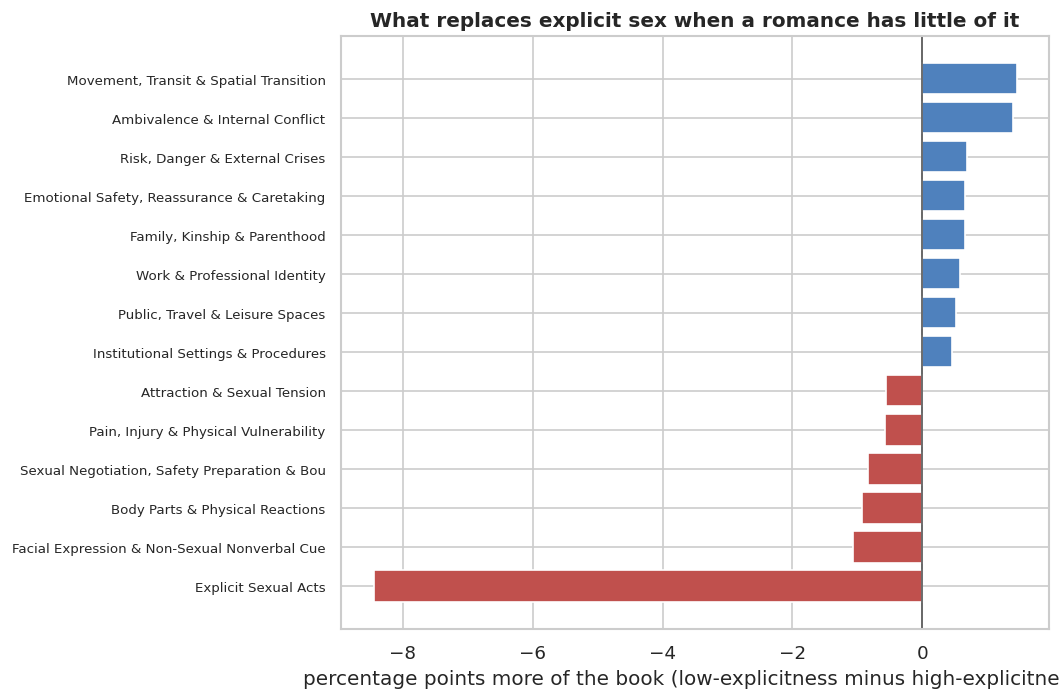

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_data = pd.concat([displacement.head(8), displacement.tail(6)])
positions = np.arange(len(plot_data))
ax.barh(positions, plot_data["difference_pp"],
        color=np.where(plot_data["difference_pp"] > 0, "#4f81bd", "#c0504d"))
ax.set_yticks(positions)
ax.set_yticklabels([str(s).split(" — ")[-1][:44] for s in plot_data["label"]], fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color="#555555", lw=1)
ax.set_xlabel("percentage points more of the book (low-explicitness minus high-explicitness)")
ax.set_title("What replaces explicit sex when a romance has little of it")
fig.tight_layout()
ctx.save_figure(fig, "explicitness_displacement")
plt.show()

## 6. Couple conflict: is the label accurate?

H5's internal-versus-external distinction rests on `4.4` being conflict *between the couple*
rather than conflict in general. That is a claim about a label, and labels are checkable.

In [15]:
print(results["couple conflict"]["target"]["claim"])
print()
show_cell(results["couple conflict"]["pack"], "high_index_low_tier", max_books=3)

Conflict, distance and breakup threats predicts REACH (+0.153) and is mildly negative on rating (-0.039) — the dark leaf that broke H5's composite.

  HIGH INDEX LOW TIER

  This Charming Man — Marian Keyes
  rating 3.75, 28,638 ratings
    · topic 85 — Offering and Refusing An Apology  (0.49% of the book)
        I’m sorry, I’m sorry, I’m sorry,’ he’d said, into my flabbergasted ears. ‘
        I’m just so…’ He looked disappointed, hurt, something… ‘Sorry.’
    · topic 24 — Confronting An Unwanted Marriage  (0.42% of the book)
        Suddenly he declared, almost in anguish, ‘Look, I’m married!
        She’d wanted to get married, she always had, it was what you did, it was normal
        behaviour.

  American Diva — Julia London
  rating 3.77, 609 ratings
    · topic 256 — Refusing to Let It End  (0.23% of the book)
        But it will be over before you know it, and you don’t need to . . .
        It was enough that she had to end it—to say when seemed impossible at the moment.
   

In [16]:
conflict_topics = leaf_topics("4.4")
conflict_detail = topic_lookup[topic_lookup["topic_id"].isin(conflict_topics)][
    ["topic_id", "label", "scene_summary", "taxonomy_confidence", "taxonomy_evidence_quality"]
]
display(conflict_detail)
ctx.save_table(conflict_detail, "conflict_topic_detail")
print(
    "\nThe scene summaries are the LLM's own description of each cluster, written before any\n"
    "taxonomy mapping. They are the cleanest available evidence on whether the leaf name is\n"
    "faithful to its contents."
)

,topic_id,label,scene_summary,taxonomy_confidence,taxonomy_evidence_quality
3,3,Demanding An Explanation,"A character confronts another harshly, insisti...",0.6200,low
23,24,Confronting An Unwanted Marriage,Characters argue over a forced or arranged mar...,0.8200,medium
83,85,Offering and Refusing An Apology,A character offers a sincere apology while ano...,0.7200,medium
101,103,Last Honest Conversation Before Parting,"Two characters share a final, candid exchange,...",0.5200,low
126,129,Accused of Not Caring,A character is confronted with the charge that...,0.6200,low
205,210,Expelled For Pursuing A Relationship,A character is warned that pursuing a romantic...,0.8200,medium
248,256,Refusing to Let It End,A character insists the conflict is not over w...,0.7800,medium
296,316,Snapping Over Money and Control,A man snaps angrily about money and paying oth...,0.7200,medium


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/conflict_topic_detail.csv  (8 rows)

The scene summaries are the LLM's own description of each cluster, written before any
taxonomy mapping. They are the cleanest available evidence on whether the leaf name is
faithful to its contents.


### `4.4` is faithfully labelled, and H5's reading holds

This check passes. The extracts are unmistakably intra-couple: apologies offered and refused,
a confession of being married, someone deciding when to end it, a last honest conversation
before parting. The topics carrying them — "Offering and Refusing An Apology", "Refusing to Let
It End", "Last Honest Conversation Before Parting" — describe their own contents accurately.

So notebook 05's distinction survives: `4.4` really is the couple in conflict, and `7.2` really
is threat from outside. The claim that well-rated romance carries more external danger and
slightly less internal quarrelling is supported at the level of what the text says.

Worth noticing that Marian Keyes's *This Charming Man* sits in the low-rated cell with 28,638
ratings — one of the most-read books in the corpus at 3.75 stars. That single book is notebook
06's whole finding in miniature: conflict-heavy books reach many readers and are rated
middlingly.

## 7. The label fidelity audit — the most consequential section here

Every result in this analysis inherits the quality of two upstream steps: the Stage08 LLM
label for each topic, and the Stage09 mapping of that topic to a taxonomy leaf. Neither has
been checked against the prose until now.

The audit takes the top-mass topic in each headline leaf and prints its label, its scene
summary, its keywords, and its highest-confidence sentences from a random 120-book sample.
Read the sentences and ask whether the label describes them.

In [17]:
audit_leaves = ["1.6", "7.2", "2.3", "4.4", "4.6", "9.2"]
audit_topics = (
    topic_lookup[topic_lookup["taxonomy_main_id"].isin(audit_leaves)]
    .merge(
        book_topic_counts.groupby("topic_id", as_index=False)["n_sentences"].sum(),
        on="topic_id", how="left",
    )
    .sort_values(["taxonomy_main_id", "n_sentences"], ascending=[True, False])
    .groupby("taxonomy_main_id", as_index=False)
    .head(1)
)
display(audit_topics[["topic_id", "label", "taxonomy_main_id", "taxonomy_main_name",
                      "n_sentences", "taxonomy_confidence"]])

rng = np.random.default_rng(SEED)
audit_books = rng.choice(frame["book_id"].to_numpy(), 120, replace=False).tolist()
audit_raw = qual.fetch_sentences(
    SENTENCE_FILES, audit_books, audit_topics["topic_id"].astype(int).tolist(),
    per_book_topic=3, threads=8,
)
audit_raw = audit_raw[audit_raw["sentence"].str.len() >= MIN_SENTENCE_CHARS]
audit_raw = audit_raw.sort_values("max_topic_prob", ascending=False)

for row in audit_topics.itertuples():
    subset = audit_raw[audit_raw["topic_id"] == row.topic_id].head(4)
    print("-" * 92)
    print(f"Topic {row.topic_id} | leaf {row.taxonomy_main_id} — {row.taxonomy_main_name}")
    print(f"LLM label: {row.label}")
    print(f"LLM scene summary: {row.scene_summary}")
    print(f"Keywords: {row.keywords}")
    print("Highest-confidence sentences in a random 120-book sample:")
    for _, sentence_row in subset.iterrows():
        text = " ".join(str(sentence_row["sentence"]).split())
        for line in textwrap.wrap(text, width=86)[:3]:
            print(f"    {line}")
    print()

audit_export = audit_raw.merge(
    audit_topics[["topic_id", "label", "taxonomy_main_id", "taxonomy_main_name"]],
    on="topic_id", how="left",
)
ctx.save_table(audit_export, "label_audit_sentences")

,topic_id,label,taxonomy_main_id,taxonomy_main_name,n_sentences,taxonomy_confidence
47,170,Staying Close Despite Long Separation,1.6,Character Appearance & Self-Presentation,630913,0.5800
0,1,Straps Sliding Down Her Arms,2.3,Explicit Sexual Acts,990536,0.8200
1,3,Demanding An Explanation,4.4,"Conflict, Distance & Breakup Threats",3753131,0.6200
2,6,Whispered Reassurance,4.6,"Emotional Safety, Reassurance & Caretaking",2021355,0.7800
24,87,Threatening Death As A Warning,7.2,"Violence, Threats & Non-Sexual Coercion",436050,0.8500
6,20,Warning About Doing Things Right,9.2,"Promise, Vow & Future-Tense Speech Acts",1690317,0.5800


--------------------------------------------------------------------------------------------
Topic 170 | leaf 1.6 — Character Appearance & Self-Presentation
LLM label: Staying Close Despite Long Separation
LLM scene summary: Two people reflect on how months apart and busy lives have not weakened their bond or shared history.
Keywords: separate, session, visits, scenario, guarantee, creatures, stunning, exciting, exact, regular
Highest-confidence sentences in a random 120-book sample:
    They had made an instant and deep connection that made them feel like they’d known
    each other their entire lives.
    It was as if all barriers between them had finally been removed, and they were free to
    show their love for each other.
    The little bit of history they shared was long gone and the new relationship they
    forged would be based on nothing permanent or emotional, and when it was safe, they’d
    walk away from each other to find their futures separately.
    Why couldn’t their

### Two labels match their sentences. Two do not.

**`7.2` Violence — passes.** Topic 87 "Threatening Death As A Warning" returns
*"I won't make it out of here alive so you may as well kill me now"* and *"I oughta kill you
now and forget about the extra money I get for bringing you in alive"*. The label is accurate
and the content is unambiguously external threat. The strongest finding in the analysis rests
on a topic that says what it means.

**`4.4` Conflict — passes.** Topic 3 "Demanding An Explanation" returns confrontational
dialogue demanding answers. Accurate.

**`1.6` Appearance — fails on its largest topic.** Topic 170, which carries more of this leaf
than any other, is labelled "Staying Close Despite Long Separation" and returns *"They had
made an instant and deep connection..."* and *"It was as if all barriers between them had
finally been removed"*. That is relationship content. It has been mapped into a leaf called
Character Appearance & Self-Presentation, and it does not belong there.

**`2.3` Explicit Sexual Acts — fails on register.** Topic 1, the leaf's largest, returns
*"His lips brush against my ear while his hands slide around my waist"* and *"he leans down and
places a sloppy kiss on my lips"*. Kissing. Not explicit sexual acts.

The next cell stops this being an impressionistic complaint and turns it into a number.

### How much of each headline leaf is actually on-label?

The topics in each leaf are adjudicated by hand against their own scene summaries, and the
verdict is recorded explicitly below so it can be disputed. This is a judgement call, and
labelling it as one is better than burying it.

In [18]:
# Topics judged on-label for their leaf, read against their own Stage08 scene summaries. The
# full topic lists are printed below each verdict so the adjudication can be checked.
#   1.6  keep the six topics describing dress, grooming, hair or looks; drop the rest, which
#        cover emotional closeness, photography, colours, window-watching, flowers, farewells
#        and insults.
#   2.3  keep only the four topics describing explicit acts; kissing, undressing and embracing
#        are physical intimacy but not what the leaf name claims.
#   7.2  all thirteen topics describe threat, weapons, captivity or coercion.
#   4.4  keep everything except institutional expulsion, which is pressure from outside the
#        couple rather than conflict within it.
ON_LABEL = {
    "1.6": {18, 218, 364, 77, 253, 171},
    "2.3": {208, 292, 63, 230},
    "7.2": {87, 78, 91, 113, 82, 249, 114, 117, 294, 51, 269, 148, 329},
    "4.4": {3, 85, 24, 256, 103, 129, 316},
}

fidelity_rows = []
for leaf, on_label in ON_LABEL.items():
    topics = topic_lookup[topic_lookup["taxonomy_main_id"] == leaf][
        ["topic_id", "label", "scene_summary", "taxonomy_confidence",
         "taxonomy_evidence_quality"]
    ].merge(
        book_topic_counts.groupby("topic_id", as_index=False)["n_sentences"].sum(),
        on="topic_id", how="left",
    )
    topics["on_label"] = topics["topic_id"].isin(on_label)
    topics["share_of_leaf"] = topics["n_sentences"] / topics["n_sentences"].sum()
    topics["leaf"] = leaf
    fidelity_rows.append(topics)

fidelity = pd.concat(fidelity_rows, ignore_index=True)
ctx.save_table(fidelity, "leaf_label_fidelity_detail")

summary = fidelity.groupby("leaf").apply(
    lambda g: pd.Series({
        "n_topics": len(g),
        "n_on_label": int(g["on_label"].sum()),
        "on_label_mass": g.loc[g["on_label"], "share_of_leaf"].sum(),
        "mean_confidence_on_label": g.loc[g["on_label"], "taxonomy_confidence"].mean(),
        "mean_confidence_off_label": g.loc[~g["on_label"], "taxonomy_confidence"].mean(),
    }), include_groups=False,
).reset_index()
summary["leaf_name"] = summary["leaf"].map(
    topic_lookup.drop_duplicates("taxonomy_main_id")
    .set_index("taxonomy_main_id")["taxonomy_main_name"]
)
display(summary.round(3))
ctx.save_table(summary, "leaf_label_fidelity")

print("\nThe adjudication in full, so the verdicts above can be checked topic by topic:")
for leaf in ON_LABEL:
    subset = fidelity[fidelity["leaf"] == leaf].sort_values("share_of_leaf", ascending=False)
    print(f"\n  --- leaf {leaf} ---")
    for row in subset.itertuples():
        mark = "  on" if row.on_label else " OFF"
        print(f"   {mark} | {row.share_of_leaf:6.1%} | conf {row.taxonomy_confidence:.2f} "
              f"| {row.label}")

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/leaf_label_fidelity_detail.csv  (43 rows)


,leaf,n_topics,n_on_label,on_label_mass,mean_confidence_on_label,mean_confidence_off_label,leaf_name
0,1.6,15.0000,6.0000,0.4810,0.7900,0.6000,Character Appearance & Self-Presentation
1,2.3,7.0000,4.0000,0.2760,0.8380,0.8170,Explicit Sexual Acts
2,4.4,8.0000,7.0000,0.9760,0.6860,0.8200,"Conflict, Distance & Breakup Threats"
3,7.2,13.0000,13.0000,1.0000,0.7630,NaN,"Violence, Threats & Non-Sexual Coercion"


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/leaf_label_fidelity.csv  (4 rows)

The adjudication in full, so the verdicts above can be checked topic by topic:

  --- leaf 1.6 ---
    OFF |  16.8% | conf 0.58 | Staying Close Despite Long Separation
     on |  14.4% | conf 0.65 | Ordering A Gown For Her
     on |  12.9% | conf 0.78 | Resenting Someone More Attractive
     on |   6.7% | conf 0.85 | Noticing What He Wears
     on |   6.1% | conf 0.72 | Haircut and Grooming Offered
    OFF |   5.8% | conf 0.62 | Photographer Reviewing Pictures
    OFF |   5.8% | conf 0.55 | Vivid Colors Remarked Upon
    OFF |   5.7% | conf 0.72 | Peeking Through The Window
     on |   5.3% | conf 0.92 | Hair Pinned Up in Style
    OFF |   4.4% | conf 0.52 | Flowers Held With Guilty Glance
    OFF |   3.6% | conf 0.52 | Polite Address Under Distress
    OFF |   3.6% | conf 0.62 | Saying Goodnight Before Bed
    OFF |  

  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/figures/leaf_label_fidelity.png


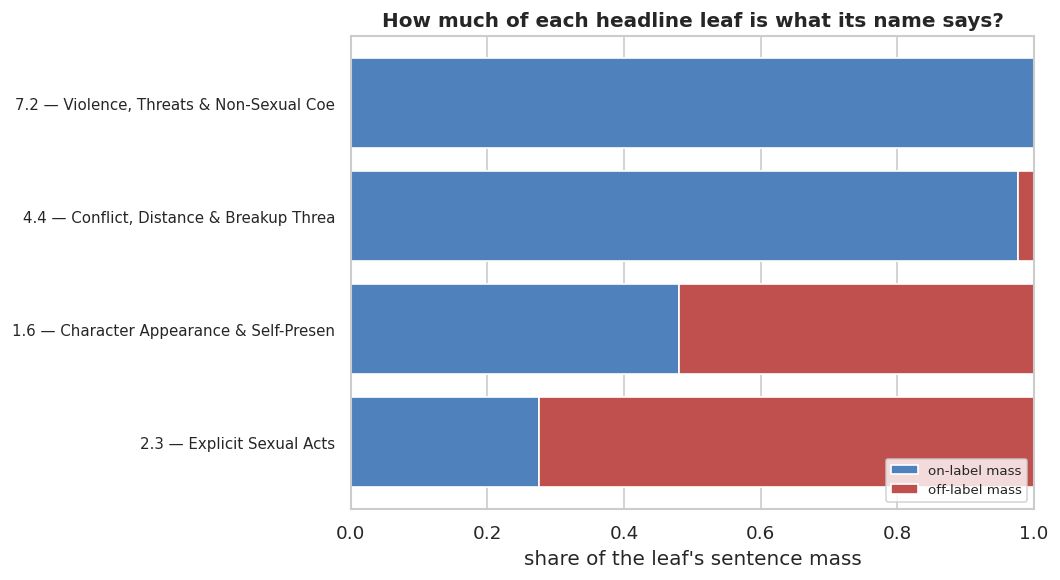

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_frame = summary.sort_values("on_label_mass")
positions = np.arange(len(plot_frame))
ax.barh(positions, plot_frame["on_label_mass"], color="#4f81bd", label="on-label mass")
ax.barh(positions, 1 - plot_frame["on_label_mass"], left=plot_frame["on_label_mass"],
        color="#c0504d", label="off-label mass")
ax.set_yticks(positions)
ax.set_yticklabels([f"{r.leaf} — {str(r.leaf_name)[:34]}" for r in plot_frame.itertuples()],
                   fontsize=9)
ax.axvline(1.0, color="#555555", lw=1)
ax.set_xlabel("share of the leaf's sentence mass")
ax.set_title("How much of each headline leaf is what its name says?")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
ctx.save_figure(fig, "leaf_label_fidelity")
plt.show()

### What this does to the four headline findings

| Leaf | On-label mass | Consequence for the finding |
|---|---|---|
| `7.2` violence | **100%** — all 13 topics | Intact. The largest effect in the analysis measures what it claims. |
| `4.4` conflict | **98%** | Intact. H5's internal-versus-external distinction stands. |
| `2.3` explicit sex | **28%** | **Must be renamed.** The leaf measures physical intimacy broadly — kissing, undressing, embracing and explicit acts together. H1's "sex" leg was never specifically about explicit sex. |
| `1.6` appearance | **48%** | **Weakened.** Half the mass is on-label description; the rest is a mixture including a large relationship topic. The −0.145 effect is real, its interpretation is not secure. |

For H1 this is a reinterpretation rather than a caveat. Notebook 05 reported that emotional
safety and "explicit sex" both rise in well-rated books, breaking the predicted trade-off.
With `2.3` understood as physical intimacy in general, that result becomes coherent rather
than paradoxical: **well-rated romance has more of both emotional and physical intimacy.** The
trade-off H1 predicted was between two things that turn out to be facets of one dimension —
how much attention the prose gives to what passes between the two characters.

For appearance, the honest position is that the effect is reliable, sizeable, and not
adequately explained. The craft hypothesis from notebook 05 should be withdrawn rather than
defended; nothing in the text supports it.

### The mapping confidence field does not identify the bad mappings

This was worth checking, and the answer is unhelpful in an interesting way. If Stage09's own
confidence scores flagged the off-label topics, filtering on them would fix the problem
cheaply. They do not:

- `1.6`: on-label topics average 0.79 confidence, off-label 0.60 — here it works.
- `2.3`: 0.84 against 0.82 — no separation at all. The kissing topics mapped into "Explicit
  Sexual Acts" were mapped *confidently*.
- `4.4`: 0.69 against 0.82 — backwards. The single off-label topic is the more confident one.

Confidence measures how sure the model was, not whether it was right, and the two come apart
exactly where it matters. Notebook 08 still runs the low-confidence exclusion, but this result
means a clean pass on that check should not be read as evidence that mapping fidelity is fine.
The only thing that surfaced these problems was reading the sentences.

### The scale of the exposure, corpus-wide

The evidence-quality field records how well grounded each mapping was. It cannot identify
*which* mappings are wrong, as just shown, but it does say how much of the analysis rests on
mappings the pipeline declined to vouch for.

In [20]:
topic_mass = (
    topic_lookup.merge(
        book_topic_counts.groupby("topic_id", as_index=False)["n_sentences"].sum(),
        on="topic_id", how="left",
    )
)
mapped_total = topic_mass["n_sentences"].sum()
quality_profile = topic_mass.groupby("taxonomy_evidence_quality", dropna=False).agg(
    n_topics=("topic_id", "size"), sentences=("n_sentences", "sum"),
).reset_index()
quality_profile["share_of_mass"] = quality_profile["sentences"] / mapped_total
display(quality_profile.round(4))

band_profile = topic_mass.groupby("taxonomy_confidence_band", dropna=False).agg(
    n_topics=("topic_id", "size"), sentences=("n_sentences", "sum"),
).reset_index()
band_profile["share_of_mass"] = band_profile["sentences"] / mapped_total
display(band_profile.round(4))
ctx.save_table(quality_profile, "evidence_quality_profile")
ctx.save_table(band_profile, "confidence_band_profile")

low_evidence_mass = float(
    quality_profile.loc[quality_profile["taxonomy_evidence_quality"] == "low", "share_of_mass"]
    .sum()
)
print(
    f"\n{low_evidence_mass:.1%} of all mapped sentence mass sits in topics whose Stage09 mapping\n"
    "was recorded as resting on LOW evidence quality, and only a third of the mass carries a\n"
    "'high' confidence band.\n"
)
print(
    "Nearly half the measurement in this analysis therefore rests on mappings the pipeline\n"
    "itself declined to vouch for. That does not make them wrong — the close reading found 7.2\n"
    "and 4.4 to be accurately mapped — but it does set the ceiling on how much weight any single\n"
    "leaf-level result should carry, and it is the reason this notebook exists at all."
)

,taxonomy_evidence_quality,n_topics,sentences,share_of_mass
0,high,25,8288213,0.0774
1,low,163,52307644,0.4885
2,medium,160,46491931,0.4341


,taxonomy_confidence_band,n_topics,sentences,share_of_mass
0,high,113,36209982,0.3381
1,medium,234,70366515,0.6571
2,NaN,1,511291,0.0048


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/evidence_quality_profile.csv  (3 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/confidence_band_profile.csv  (3 rows)

48.8% of all mapped sentence mass sits in topics whose Stage09 mapping
was recorded as resting on LOW evidence quality, and only a third of the mass carries a
'high' confidence band.

Nearly half the measurement in this analysis therefore rests on mappings the pipeline
itself declined to vouch for. That does not make them wrong — the close reading found 7.2
and 4.4 to be accurately mapped — but it does set the ceiling on how much weight any single
leaf-level result should carry, and it is the reason this notebook exists at all.


## 8. Two books that are not romance novels

Reading twenty-four books turned up two whose sentences are not fiction: a clothing-history
reference text and a First World War military history. Both entered through the corpus's EPUB
metadata, both scored at an index extreme, and neither would have been detectable from any
aggregate table.

Finding two in twenty-four does not mean 8% of the corpus is contaminated — the sampling
deliberately targeted extremes, which is exactly where such books land. But it does mean the
rate is not zero, so it is worth a systematic look.

In [21]:
# Books with almost no sexuality or relationship content are candidates: a romance novel that
# spends under a tenth of its sentences on either is unusual enough to inspect.
CORE_LEAVES = [
    c for c in nbh.columns_with_prefix(frame, "abs_leaf_")
    if c.split("_")[-1][0] in {"2", "4"}
]
frame["romance_core_mass"] = frame[CORE_LEAVES].sum(axis=1)

suspects = frame.nsmallest(20, "romance_core_mass")[
    ["book_id", "romance_core_mass", "n_sentences", TIER_COL, "n_ratings", "genre_group"]
].merge(books_meta[["book_id", "title", "author_name"]], on="book_id", how="left")
display(suspects.round(4))
ctx.save_table(suspects, "low_romance_core_books")

print(
    f"Corpus median romance-core mass: {frame['romance_core_mass'].median():.1%} of sentences.\n"
    f"Books below 10%: {int((frame['romance_core_mass'] < 0.10).sum())} "
    f"({(frame['romance_core_mass'] < 0.10).mean():.2%} of the corpus).\n"
)
bottom = frame.nsmallest(160, "romance_core_mass")
print("Rating-tier mix of the bottom 1% on romance-core mass:")
display(nbh.summarise_counts(bottom.reset_index(), TIER_COL))
print(
    "The tier mix is roughly balanced, which is the reassuring part: whatever these books are,\n"
    "they are not concentrated in one tier and so cannot be generating the tier contrasts.\n"
    "'The Great British Date Off' — the WWI history found by close reading — does appear in this\n"
    "bottom group, so the detector works, but the group is small enough not to move any result."
)

,book_id,romance_core_mass,n_sentences,rating_class,n_ratings,genre_group,title,author_name
0,7391636,0.0000,1,low_rate,"1,437.0000",young_adult,I Now Pronounce You Someone Else,Erin McCahan
1,41425178,0.0000,1,mid_rate,56.0000,other,You'll Breathe Me In,LoadedGunn
2,45095314,0.0000,5,mid_rate,99.0000,paranormal,Yummy Addictions,Belle Davis
3,52223594,0.0000,1,high_rate,89.0000,historical,What Might Have Been,Lynn Steward
4,25649656,0.0155,194,high_rate,15.0000,paranormal,"Maple Lane Manor, Home for Retired Supernaturals",Cree Walker
5,41849686,0.0482,9055,high_rate,16.0000,historical,The Devil Take Tomorrow,Gretchen Jeannette
6,21372347,0.0578,4742,mid_rate,138.0000,paranormal,The Sailor's General Superior,IceraMyst
7,24165506,0.0592,2671,low_rate,9.0000,paranormal,Simply Delicious: Synergy Sweets,Amie K. Andrews
8,16485738,0.0613,9320,low_rate,23.0000,other,Paradox,Lee Nilsen
9,21928017,0.0627,6569,high_rate,9.0000,mystery,The Ruthlessness of Cats and Dogs,S.J. Hunter


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/low_romance_core_books.csv  (20 rows)
Corpus median romance-core mass: 30.2% of sentences.
Books below 10%: 29 (0.18% of the corpus).

Rating-tier mix of the bottom 1% on romance-core mass:


,rating_class,n,percent
0,low_rate,58,36.2000
1,high_rate,58,36.2000
2,mid_rate,44,27.5000


The tier mix is roughly balanced, which is the reassuring part: whatever these books are,
they are not concentrated in one tier and so cannot be generating the tier contrasts.
'The Great British Date Off' — the WWI history found by close reading — does appear in this
bottom group, so the detector works, but the group is small enough not to move any result.


### A separate and more actionable problem: books with almost no text

The frame contains books with a handful of sentences in total. A book with one sentence has a
share of 100% on whatever topic that sentence hit, which places it at the extreme of every
distribution in this analysis.

In [22]:
tiny = frame.nsmallest(10, "n_sentences")[
    ["book_id", "n_sentences", "n_chapters", "n_topics_present", "mapped_mass",
     "analysable", TIER_COL]
].merge(books_meta[["book_id", "title"]], on="book_id", how="left")
display(tiny)
ctx.save_table(tiny, "tiny_books")

for threshold in (10, 100, 250, 500, 1000):
    count = int((frame["n_sentences"] < threshold).sum())
    print(f"  books with fewer than {threshold:>5,} sentences: {count:>4,} "
          f"({count / len(frame):.2%})")
print(
    f"\nMedian book: {frame['n_sentences'].median():,.0f} sentences. The `analysable` flag built "
    f"in\ndata preparation excluded only "
    f"{int((~frame['analysable']).sum())} book, because it screens on interpretable *mass* rather\n"
    "than on absolute length. That was an oversight worth naming: a minimum sentence count is a\n"
    "cheaper and more direct guard, and notebook 08 adds it as a sensitivity check."
)

,book_id,n_sentences,n_chapters,n_topics_present,mapped_mass,analysable,rating_class,title
0,7391636,1,1,1,0.0000,False,low_rate,I Now Pronounce You Someone Else
1,41425178,1,1,1,1.0000,True,mid_rate,You'll Breathe Me In
2,52223594,1,1,1,1.0000,True,high_rate,What Might Have Been
3,45095314,5,1,2,0.2000,True,mid_rate,Yummy Addictions
4,54787442,6,1,5,0.8333,True,high_rate,Guilty Pleasure by Lora Leigh
5,43512505,84,2,43,0.8571,True,mid_rate,I AM
6,17328409,127,2,73,0.9528,True,high_rate,Between a Rock and a Hard Place
7,21514577,154,5,40,0.9740,True,high_rate,The Long Road to Loving Grayson
8,40697830,169,2,78,0.9940,True,high_rate,Polished Shoes
9,44016475,177,1,73,0.9716,True,low_rate,A Neutrino Walks Through a Bar


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/tiny_books.csv  (10 rows)
  books with fewer than    10 sentences:    5 (0.03%)
  books with fewer than   100 sentences:    6 (0.04%)
  books with fewer than   250 sentences:   21 (0.13%)
  books with fewer than   500 sentences:   66 (0.41%)
  books with fewer than 1,000 sentences:  146 (0.91%)

Median book: 6,840 sentences. The `analysable` flag built in
data preparation excluded only 1 book, because it screens on interpretable *mass* rather
than on absolute length. That was an oversight worth naming: a minimum sentence count is a
cheaper and more direct guard, and notebook 08 adds it as a sensitivity check.


## 9. Sentence quality: a limitation the close reading makes visible

Reading real extracts surfaces something the aggregate tables cannot: a noticeable share of
the corpus's "sentences" are fragments. Dialogue tags, split quotations, and single clauses
left behind by sentence segmentation all count as one unit each in every share computed in
this analysis.

In [23]:
length_probe = qual.fetch_sentences(
    SENTENCE_FILES, audit_books[:60], None, per_book_topic=40, threads=8,
)
length_probe["n_chars"] = length_probe["sentence"].str.len()
length_probe["n_words"] = length_probe["sentence"].str.split().str.len()
length_summary = length_probe[["n_chars", "n_words"]].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
)
display(length_summary.round(1))
ctx.save_table(length_summary.reset_index(), "sentence_length_summary")

short_share = float((length_probe["n_words"] <= 4).mean())
print(
    f"\n{short_share:.1%} of sampled sentences are four words or fewer.\n"
    "Every share in this analysis weights those equally with a 40-word sentence, because the\n"
    "measure is 'fraction of sentences', not 'fraction of words'. The consequence is that\n"
    "dialogue-heavy books have systematically more units for the same amount of text, which\n"
    "inflates conversational topics relative to descriptive ones."
)

,n_chars,n_words
count,"313,257.0000","313,257.0000"
mean,55.1000,10.5000
std,40.9000,7.5000
min,1.0000,1.0000
5%,11.0000,2.0000
25%,25.0000,5.0000
50%,45.0000,9.0000
75%,74.0000,14.0000
95%,133.0000,25.0000
max,"1,014.0000",154.0000


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/sentence_length_summary.csv  (10 rows)

20.6% of sampled sentences are four words or fewer.
Every share in this analysis weights those equally with a 40-word sentence, because the
measure is 'fraction of sentences', not 'fraction of words'. The consequence is that
dialogue-heavy books have systematically more units for the same amount of text, which
inflates conversational topics relative to descriptive ones.


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/figures/sentence_length.png


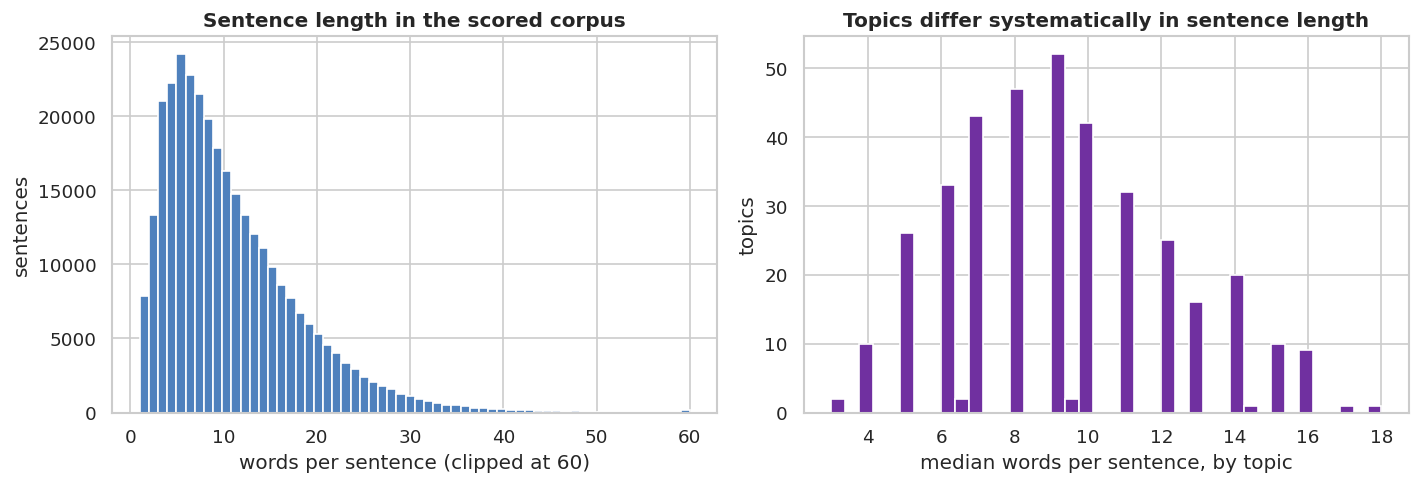

The right panel is the part that matters for interpretation: topics are not interchangeable
units of text. A topic whose median sentence is six words and one whose median is twenty-six
represent very different amounts of narrative for the same share. Notebook 08 checks whether
the headline results survive a word-weighted alternative.


In [24]:
fig, axes_row = plt.subplots(1, 2, figsize=(12, 4.2))
axes_row[0].hist(length_probe["n_words"].clip(upper=60), bins=60, color="#4f81bd")
axes_row[0].set_xlabel("words per sentence (clipped at 60)")
axes_row[0].set_ylabel("sentences")
axes_row[0].set_title("Sentence length in the scored corpus")

by_topic = length_probe.groupby("topic_id")["n_words"].median().reset_index()
axes_row[1].hist(by_topic["n_words"], bins=40, color="#7030a0")
axes_row[1].set_xlabel("median words per sentence, by topic")
axes_row[1].set_ylabel("topics")
axes_row[1].set_title("Topics differ systematically in sentence length")
fig.tight_layout()
ctx.save_figure(fig, "sentence_length")
plt.show()

print(
    "The right panel is the part that matters for interpretation: topics are not interchangeable\n"
    "units of text. A topic whose median sentence is six words and one whose median is twenty-six\n"
    "represent very different amounts of narrative for the same share. Notebook 08 checks whether\n"
    "the headline results survive a word-weighted alternative."
)

## 10. What the close reading changed

This notebook was expected to be confirmatory. It was not, and that is the argument for having
done it.

**Two findings survived and are now better understood.**

The violence result — the largest effect in the analysis — reads exactly as claimed. The
extracts are vampires, swords, guns and abductions, with no instance of the love interest
threatening the protagonist. The external-threat interpretation holds, with a new caveat that
it may partly be a paranormal-and-suspense subgenre effect, which notebook 08 can test. The
conflict leaf `4.4` is faithfully labelled, so H5's internal-versus-external distinction
stands.

**One finding was reinterpreted.** Leaf `2.3`, named "Explicit Sexual Acts", carries only about
a quarter of its mass in topics that describe explicit acts; the rest is kissing, undressing
and embracing. So H1 was never testing love against explicit sex. It was testing emotional
intimacy against physical intimacy, and the answer — that well-rated romance has more of both —
is coherent rather than paradoxical once the leaf is named correctly.

**One interpretation was withdrawn.** Notebook 05 proposed that the appearance effect was a
craft marker. The text does not support it: a 4.34-star Kenyon novel and a 3.21-star one write
clothing description the same way. The statistical effect is real and among the largest here,
and it currently has no validated explanation. Saying so is better than keeping a story that
the sentences contradict.

**Three measurement problems became visible that no aggregate table would have shown.**

1. *Mapping fidelity is uneven, and unevenly detectable.* Two of the four headline leaves are
   faithfully mapped and two are not; `2.3` carries only 28% on-label mass and `1.6` only 48%.
   Worse, Stage09's confidence scores do not separate the good mappings from the bad — on
   `4.4` they point the wrong way. Roughly half of all mapped mass sits in low-evidence
   mappings. Notebook 08's low-confidence exclusion is still worth running, but passing it
   would not establish that the mappings are sound.
2. *A small number of books are not romance novels.* Two of twenty-four sampled books are
   nonfiction. The systematic detector finds them, they are spread evenly across rating tiers,
   and they are too few to generate any tier contrast — but the rate is not zero.
3. *Sentences are not comparable units.* A fifth of them are four words or fewer, and topics
   differ several-fold in median sentence length, so equal shares do not mean equal amounts of
   narrative.

**The methodological point.** The 2x2 design with a fixed seed is what made this work. Had the
examples been chosen to illustrate the findings, the appearance craft story would have been
easy to support and the `2.3` mislabelling would never have surfaced, because a confirming
extract from topic 292 was always available. The off-diagonal cells and the forced inclusion
of the largest topic in each leaf are what turned close reading into a test rather than a
decoration.

## 11. Writing the pack to disk

The full close-reading packs, all four targets and all four cells, are written out as markdown
so they can be read outside the notebook and quoted in the write-up.

In [25]:
sections = []
for name, result in results.items():
    target = result["target"]
    sections.append(f"# {name} — {target['column']}\n")
    sections.append(f"**Claim under test.** {target['claim']}\n")
    sections.append(f"**What to check.** {target['to_check']}\n")
    sections.append(qual.render_close_reading_markdown(result["pack"], max_sentences_per_topic=2))
    ctx.save_table(result["pack"], f"close_reading_pack_{name.replace(' ', '_')}")
    ctx.save_table(result["sampled"], f"sampled_books_{name.replace(' ', '_')}")

ctx.save_markdown("\n".join(sections), "close_reading_packs")
print(f"Wrote {sum(len(r['pack']) for r in results.values()):,} extracts across "
      f"{len(results)} targets to close_reading_packs.md")
print("\nNext: 08_robustness.ipynb — which, after this notebook, has a specific job: find out")
print("whether the headline results survive dropping the topics whose mappings were never")
print("well evidenced.")

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/close_reading_pack_appearance.csv  (228 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/sampled_books_appearance.csv  (20 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/close_reading_pack_violence.csv  (163 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/sampled_books_violence.csv  (20 rows)


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/close_reading_pack_explicit_sex.csv  (176 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/sampled_books_explicit_sex.csv  (20 rows)


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/close_reading_pack_couple_conflict.csv  (131 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/sampled_books_couple_conflict.csv  (20 rows)
  saved markdown: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/07_qualitative_triangulation/tables/close_reading_packs.md
Wrote 698 extracts across 4 targets to close_reading_packs.md

Next: 08_robustness.ipynb — which, after this notebook, has a specific job: find out
whether the headline results survive dropping the topics whose mappings were never
well evidenced.
